# 🏋️ Práctica GYM — Regresión Logística (versión profesional)

**Autor:** Borja Mora Méndez  
**Objetivo:** Predecir el **abandono** de clientes de un gimnasio a partir de su comportamiento y consumo.  
**Variable target:** `Abandono` (1 = abandona, 0 = se mantiene).

## 📋 Metodología (12 pasos)

| # | Paso |
|---|------|
| 1 | Carga de datos |
| 2 | Exploración inicial (EDA) |
| 3 | Limpieza (nulos, duplicados, outliers) |
| 4 | Balance de clases |
| 5 | Análisis exploratorio (correlaciones, relaciones) |
| 6 | Detección de data leakage y selección de variables |
| 7 | División train/test estratificada |
| 8 | Modelo base con `statsmodels.Logit` (p-valores) |
| 9 | Diagnóstico: VIF + p-valores |
| 10 | Modelo final con `sklearn` (para producción) |
| 11 | Evaluación: matriz de confusión + métricas + ROC/AUC |
| 12 | Interpretación con Odds Ratios + análisis de threshold |

---

## ⚙️ Paso 0 — Imports y configuración

In [1]:
# ────────────────────────────────────────────────────────────────
# Librerías
# ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado estadístico
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Modelado para producción
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
)

# ────────────────────────────────────────────────────────────────
# Configuración estética (paleta de marca personal)
# ────────────────────────────────────────────────────────────────
COLOR_PRINCIPAL = "#7a7bff"   # morado — protagonista
COLOR_CONTEXTO = "#e5e5e5"    # gris — contexto / referencia
COLOR_POSITIVO = "#3c8a37"    # verde — favorable
COLOR_NEGATIVO = "#d94a4a"    # rojo — desfavorable

plt.rcParams["font.family"] = "Segoe UI"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


## 📂 Paso 1 — Carga de datos

In [2]:
# Carga del dataset
data = pd.read_excel(
    r"dataset_didactico_machine_learning - ALUMNOS.xlsx"
)

print("Shape del dataset:", data.shape)
data.head()


Shape del dataset: (300, 7)


,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
0,1,29,1,8.673509,64.161055,0,1
1,2,15,1,4.396600,32.554177,0,0
2,3,8,22,22.313433,85.092643,1,0
3,4,21,21,20.598791,120.709423,1,0
4,5,19,18,18.783644,103.148141,1,0


## 🔎 Paso 2 — Exploración inicial (EDA)

In [3]:
# Información general
print("─" * 60)
print("INFO DEL DATASET")
print("─" * 60)
data.info()


────────────────────────────────────────────────────────────
INFO DEL DATASET
────────────────────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_Cliente           300 non-null    int64  
 1   Antiguedad_Meses     300 non-null    int64  
 2   Asistencias_Mes      300 non-null    int64  
 3   Horas_Pico_Mes       300 non-null    float64
 4   Gasto_Mensual_Extra  300 non-null    float64
 5   Satisfecho           300 non-null    int64  
 6   Abandono             300 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 16.5 KB


In [4]:
# Estadísticos descriptivos
data.describe().round(2)


,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,150.50,18.88,12.16,14.67,81.69,0.48,0.16
std,86.75,10.60,7.27,6.09,30.47,0.50,0.37
min,1.00,1.00,0.00,1.41,10.00,0.00,0.00
25%,75.75,9.00,6.00,9.65,61.25,0.00,0.00
50%,150.50,20.00,12.00,15.07,82.24,0.00,0.00
75%,225.25,28.00,18.25,19.75,104.11,1.00,0.00
max,300.00,35.00,24.00,24.00,145.91,1.00,1.00


## 🧹 Paso 3 — Limpieza de datos

Tres comprobaciones rutinarias:
1. **Nulos** — si los hay, decidir si imputar o eliminar.
2. **Duplicados** — eliminar si los hay.
3. **Outliers** — regla IQR (informativos, no se eliminan automáticamente).

In [5]:
# 3.1 Nulos
print("Nulos por columna:")
print(data.isna().sum())


Nulos por columna:
ID_Cliente             0
Antiguedad_Meses       0
Asistencias_Mes        0
Horas_Pico_Mes         0
Gasto_Mensual_Extra    0
Satisfecho             0
Abandono               0
dtype: int64


In [6]:
# 3.2 Duplicados
print("Filas duplicadas:", data.duplicated().sum())


Filas duplicadas: 0


In [7]:
# 3.3 Outliers — regla 1.5 × IQR
numericas = ["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]

print("Detección de outliers (regla 1.5 × IQR):")
print("─" * 60)
for col in numericas:
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((data[col] < low) | (data[col] > high)).sum()
    print(col.ljust(22), "→ outliers:", n_out, "  límites: [", round(low, 1), ",", round(high, 1), "]")


Detección de outliers (regla 1.5 × IQR):
────────────────────────────────────────────────────────────
Antiguedad_Meses       → outliers: 0   límites: [ -19.5 , 56.5 ]
Asistencias_Mes        → outliers: 0   límites: [ -12.4 , 36.6 ]
Horas_Pico_Mes         → outliers: 0   límites: [ -5.5 , 34.9 ]
Gasto_Mensual_Extra    → outliers: 0   límites: [ -3.0 , 168.4 ]


## ⚖️ Paso 4 — Balance de clases

Paso **crítico** en clasificación. Si la clase 1 representa menos del 20%, hablamos de un dataset **desbalanceado** y hay que:
- Usar `stratify=y` al dividir.
- Mirar específicamente recall/precision/specificity (no solo accuracy).
- Plantear si conviene `class_weight='balanced'` o ajustar el threshold.

In [8]:
# Conteo absoluto y relativo
balance = data["Abandono"].value_counts(normalize=True).round(3) * 100
balance_abs = data["Abandono"].value_counts()

print("Distribución de la variable target 'Abandono':")
print("─" * 50)
print("No abandono (0):", balance_abs[0], "casos -", round(balance[0], 1), "%")
print("Abandono    (1):", balance_abs[1], "casos -", round(balance[1], 1), "%")


Distribución de la variable target 'Abandono':
──────────────────────────────────────────────────
No abandono (0): 251 casos - 83.7 %
Abandono    (1): 49 casos - 16.3 %


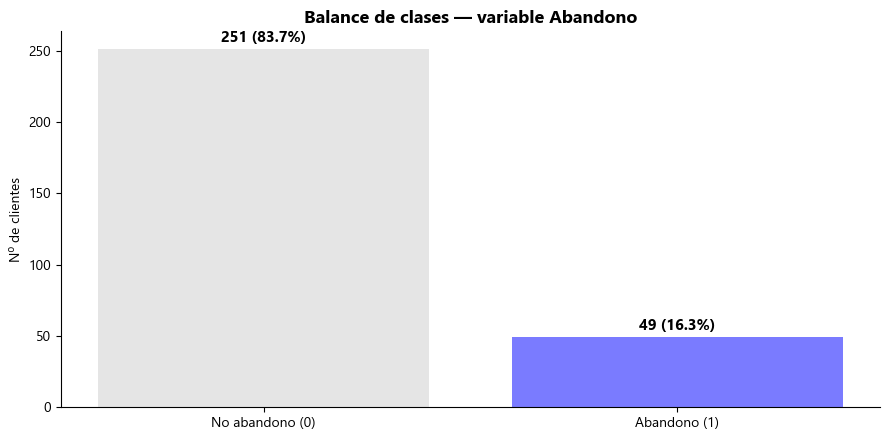

In [9]:
# Visualización del balance
fig, ax = plt.subplots(figsize=(9, 4.5))

colores = [COLOR_CONTEXTO, COLOR_PRINCIPAL]
ax.bar(["No abandono (0)", "Abandono (1)"], balance_abs.values, color=colores)

for i, v in enumerate(balance_abs.values):
    ax.text(i, v + 5, str(v) + " (" + str(round(balance.iloc[i], 1)) + "%)",
            ha="center", fontsize=11, weight="bold")

ax.set_title("Balance de clases — variable Abandono", fontsize=13, weight="bold")
ax.set_ylabel("Nº de clientes")
plt.tight_layout()
plt.show()


> ⚠️ **Diagnóstico**: el dataset está **desbalanceado** (~84% / ~16%). Esto significa que la `accuracy` por sí sola engaña: un modelo tonto que prediga siempre "no abandona" ya tendría un 84% de accuracy sin haber aprendido nada. Tendremos que mirar **recall, precision, specificity y AUC** para evaluar el modelo de verdad.

## 📊 Paso 5 — Análisis exploratorio

Antes de modelar, queremos entender cómo se relacionan las predictoras entre sí y con la Y.

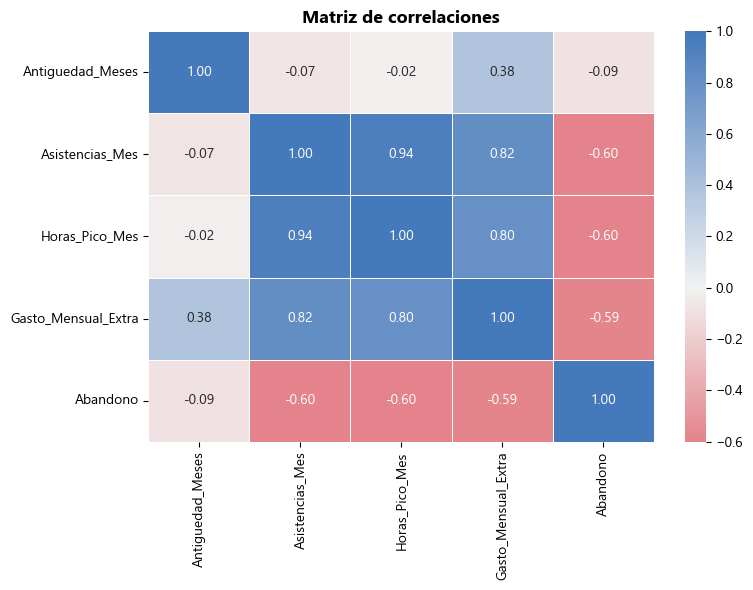

In [10]:
# Matriz de correlaciones (solo numéricas)
cols_num = ["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra", "Abandono"]
corr = data[cols_num].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap=sns.diverging_palette(10, 250, as_cmap=True),
    center=0,
    fmt=".2f",
    cbar=True,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)
ax.set_title("Matriz de correlaciones", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()


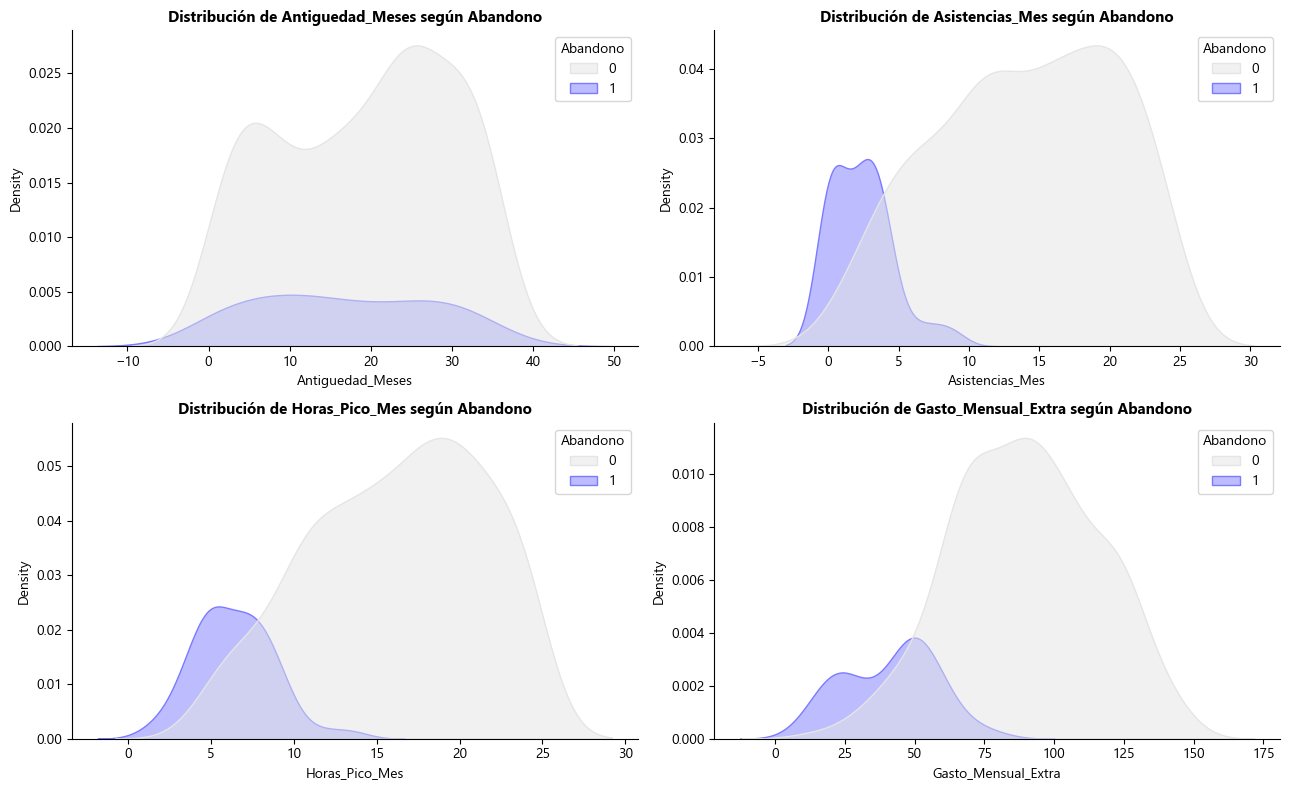

In [11]:
# Comparativa visual: distribución de variables clave según Abandono
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

variables_plot = ["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]

for ax, var in zip(axes.flatten(), variables_plot):
    sns.kdeplot(data=data, x=var, hue="Abandono",
                palette={0: COLOR_CONTEXTO, 1: COLOR_PRINCIPAL},
                fill=True, alpha=0.5, ax=ax)
    ax.set_title("Distribución de " + var + " según Abandono", fontsize=11, weight="bold")
    ax.set_xlabel(var)

plt.tight_layout()
plt.show()


**Lectura**: los clientes que abandonan tienden a tener menos asistencias, menos horas en horario pico y menor gasto extra. Esto encaja con la intuición de negocio.

## 🚨 Paso 6 — Detección de data leakage y selección de variables

**Pregunta clave**: ¿alguna variable encierra información que solo conoceríamos DESPUÉS de saber si el cliente abandonó?

| Variable | ¿Usar? | Motivo |
|----------|--------|--------|
| `ID_Cliente` | ❌ | Identificador, no es predictiva |
| `Antiguedad_Meses` | ✅ | Información histórica del cliente |
| `Asistencias_Mes` | ✅ | Comportamiento medible en tiempo real |
| `Horas_Pico_Mes` | ✅ | Comportamiento medible en tiempo real |
| `Gasto_Mensual_Extra` | ✅ | Comportamiento medible en tiempo real |
| `Satisfecho` | ❌ | **Sospecha de data leakage**: la satisfacción se mide en encuestas que probablemente se hacen después del abandono o como consecuencia del descontento. Si fuera información previa documentada del cliente sí podría usarse, pero ante la duda → fuera. |
| `Abandono` | ❌ | Es la Y (target) |

In [12]:
# Definimos X e Y
X = data[["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]]
y = data["Abandono"]

print("Variables predictoras (X):", list(X.columns))
print("Variable target (y):     ", y.name)


Variables predictoras (X): ['Antiguedad_Meses', 'Asistencias_Mes', 'Horas_Pico_Mes', 'Gasto_Mensual_Extra']
Variable target (y):      Abandono


## ✂️ Paso 7 — División Train / Test (estratificada)

`stratify=y` mantiene el ~16% de positivos en ambos splits. Sin esto, podríamos quedarnos con un test sin apenas casos de abandono y métricas sin sentido.

In [13]:
# División estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print("Tamaño TRAIN:", X_train.shape, "  Tamaño TEST:", X_test.shape)
print("─" * 50)
print("Balance en TRAIN:", round(y_train.mean() * 100, 1), "% positivos")
print("Balance en TEST: ", round(y_test.mean() * 100, 1), "% positivos")


Tamaño TRAIN: (225, 4)   Tamaño TEST: (75, 4)
──────────────────────────────────────────────────
Balance en TRAIN: 16.4 % positivos
Balance en TEST:  16.0 % positivos


## 📐 Paso 8 — Modelo base con `statsmodels.Logit`

`statsmodels` nos da p-valores, intervalos de confianza y `summary()` rico. Es el equivalente a `sm.OLS` en regresión lineal, pero para clasificación. Lo usamos para **diagnóstico** y **interpretación**.

In [14]:
# Añadimos la constante (intercepto)
X_train_sm = sm.add_constant(X_train).astype(float)
X_test_sm = sm.add_constant(X_test).astype(float)

# Ajuste del modelo Logit (Maximum Likelihood Estimation)
modelo_logit = sm.Logit(y_train, X_train_sm).fit(disp=False)

# Resumen completo
print(modelo_logit.summary())


                           Logit Regression Results                           
Dep. Variable:               Abandono   No. Observations:                  225
Model:                          Logit   Df Residuals:                      220
Method:                           MLE   Df Model:                            4
Date:                Tue, 30 Jun 2026   Pseudo R-squ.:                  0.6243
Time:                        19:26:14   Log-Likelihood:                -37.784
converged:                       True   LL-Null:                       -100.57
Covariance Type:            nonrobust   LLR p-value:                 3.451e-26
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   5.5714      1.308      4.261      0.000       3.008       8.134
Antiguedad_Meses       -0.0303      0.042     -0.712      0.476      -0.114       0.053
Asistencias_Mes 

**Cómo leer este summary**:

- `Pseudo R-squ.` (McFadden): valores entre 0.2 y 0.4 ya se consideran muy buenos en clasificación.
- `LLR p-value`: si es < 0.05, el modelo global es estadísticamente significativo.
- `P>|z|` por variable: si es < 0.05, esa variable es significativa.
- `coef` por variable: el signo nos dice si influye positiva (+) o negativamente (−) en la probabilidad de abandono.

## 🩺 Paso 9 — Diagnóstico: VIF + p-valores

### 9.1 VIF (multicolinealidad)
Comprobamos que no haya variables redundantes. Referencia: VIF < 5 es bueno.

In [15]:
# Cálculo del VIF para cada predictora
X_vif = X_train.astype(float)
vif = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
}).sort_values("VIF", ascending=False)

vif.round(2)


,Variable,VIF
3,Gasto_Mensual_Extra,62.77
1,Asistencias_Mes,43.27
2,Horas_Pico_Mes,38.21
0,Antiguedad_Meses,11.49


### 9.2 P-valores ordenados
Si alguna variable tiene p > 0.05, sería candidata a salir del modelo (eliminación iterativa).

In [16]:
pvals = modelo_logit.pvalues.sort_values(ascending=False)
print("P-valores ordenados (más altos arriba):")
print(pvals.round(4))


P-valores ordenados (más altos arriba):
Antiguedad_Meses       0.4762
Gasto_Mensual_Extra    0.1577
Asistencias_Mes        0.0961
Horas_Pico_Mes         0.0393
const                  0.0000
dtype: float64


> ⚠️ **Si ves alguna variable con p > 0.05**, quítala del modelo, reajusta y vuelve a mirar. La eliminación es **iterativa, una a una**, empezando por la peor.

## 🤖 Paso 10 — Modelo final con `sklearn` (para predicción y producción)

`sklearn.LogisticRegression` es lo que usaremos para **predecir en producción**. Statsmodels lo usamos para **interpretar**; sklearn lo usamos para **operar**.

⚠️ **Atención al orden**: primero `.fit()`, luego inspeccionar coeficientes. Si pides `.intercept_` o `.coef_` antes de entrenar, Python lanza `AttributeError`.

In [17]:
# 1. Crear el modelo
model = LogisticRegression(max_iter=1000)

# 2. Entrenar (CRÍTICO: hacerlo ANTES de inspeccionar coeficientes)
model.fit(X_train, y_train)

# 3. Inspeccionar coeficientes (ahora sí existen)
print("Intercepto (β0):", round(model.intercept_[0], 4))
print()

print("Coeficientes (β):")
for variable, beta in zip(X_train.columns, model.coef_[0]):
    print(variable.ljust(22), ":", round(beta, 4))


Intercepto (β0): 5.5416

Coeficientes (β):
Antiguedad_Meses       : -0.0293
Asistencias_Mes        : -0.272
Horas_Pico_Mes         : -0.2971
Gasto_Mensual_Extra    : -0.0385


## 📊 Paso 11 — Predicción y evaluación

Trabajamos con dos cosas:
- **`y_pred`** (clases 0/1) → para matriz de confusión, accuracy, precision, recall, specificity, F1.
- **`y_prob`** (probabilidades 0–1) → para curva ROC, AUC y análisis de threshold.

⚠️ **Error frecuente**: pasar `y_pred` a `roc_curve` o `roc_auc_score`. Hay que pasar **`y_prob`**.

In [18]:
# Clases predichas (threshold por defecto = 0.5)
y_pred = model.predict(X_test)

# Probabilidades predichas para la clase 1
y_prob = model.predict_proba(X_test)[:, 1]

print("Primeras 10 probabilidades predichas:")
print(np.round(y_prob[:10], 3))


Primeras 10 probabilidades predichas:
[0.002 0.    0.622 0.043 0.934 0.019 0.    0.    0.    0.001]


### 11.1 Matriz de confusión

In [19]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("─" * 50)
print("MATRIZ DE CONFUSIÓN (threshold = 0.5)")
print("─" * 50)
print("                  Predicho 0    Predicho 1")
print("Real 0           ", str(tn).rjust(10), str(fp).rjust(14))
print("Real 1           ", str(fn).rjust(10), str(tp).rjust(14))
print()
print("TN (aciertos en 0):", tn)
print("FP (falsa alarma): ", fp)
print("FN (no detectado): ", fn)
print("TP (acierto en 1): ", tp)


──────────────────────────────────────────────────
MATRIZ DE CONFUSIÓN (threshold = 0.5)
──────────────────────────────────────────────────
                  Predicho 0    Predicho 1
Real 0                    62              1
Real 1                     5              7

TN (aciertos en 0): 62
FP (falsa alarma):  1
FN (no detectado):  5
TP (acierto en 1):  7


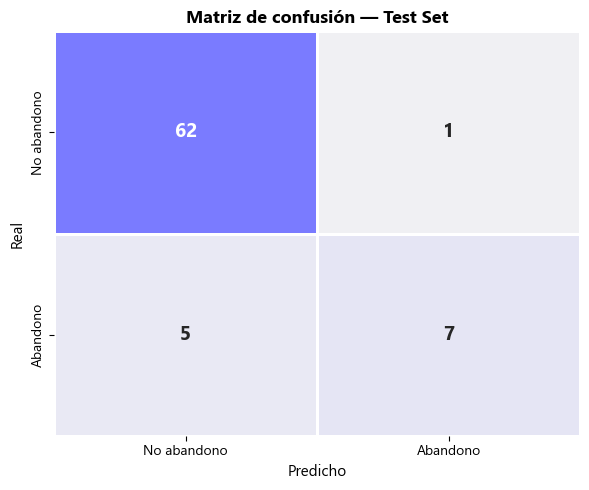

In [20]:
# Heatmap visual
fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=sns.light_palette(COLOR_PRINCIPAL, as_cmap=True),
    cbar=False,
    linewidths=1,
    linecolor="white",
    xticklabels=["No abandono", "Abandono"],
    yticklabels=["No abandono", "Abandono"],
    annot_kws={"size": 14, "weight": "bold"},
    ax=ax,
)
ax.set_xlabel("Predicho", fontsize=11)
ax.set_ylabel("Real", fontsize=11)
ax.set_title("Matriz de confusión — Test Set", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()


### 11.2 Métricas — las 5 grandes

In [21]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0           # Sensitivity
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0      # ← AÑADIDA
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("─" * 60)
print("MÉTRICAS DE CLASIFICACIÓN")
print("─" * 60)
print("Accuracy    :", round(accuracy, 3), "  →  (TP+TN) / Total")
print("Precision   :", round(precision, 3), "  →  TP / (TP+FP) — de los que predigo 1, % real 1")
print("Recall      :", round(recall, 3), "  →  TP / (TP+FN) — de los 1 reales, % detectados")
print("Specificity :", round(specificity, 3), "  →  TN / (TN+FP) — de los 0 reales, % descartados bien")
print("F1-Score    :", round(f1, 3), "  →  media armónica precision-recall")


────────────────────────────────────────────────────────────
MÉTRICAS DE CLASIFICACIÓN
────────────────────────────────────────────────────────────
Accuracy    : 0.92   →  (TP+TN) / Total
Precision   : 0.875   →  TP / (TP+FP) — de los que predigo 1, % real 1
Recall      : 0.583   →  TP / (TP+FN) — de los 1 reales, % detectados
Specificity : 0.984   →  TN / (TN+FP) — de los 0 reales, % descartados bien
F1-Score    : 0.7   →  media armónica precision-recall


In [22]:
# Reporte completo de sklearn
print(classification_report(y_test, y_pred, target_names=["No abandono", "Abandono"]))


              precision    recall  f1-score   support

 No abandono       0.93      0.98      0.95        63
    Abandono       0.88      0.58      0.70        12

    accuracy                           0.92        75
   macro avg       0.90      0.78      0.83        75
weighted avg       0.92      0.92      0.91        75



### 11.3 Curva ROC y AUC

⚠️ **Aquí va `y_prob`, NO `y_pred`**. La curva ROC necesita la probabilidad continua para barrer todos los thresholds.

In [23]:
# Cálculo de la curva ROC (usando y_prob, ¡no y_pred!)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

print("AUC =", round(auc, 4))


AUC = 0.9775


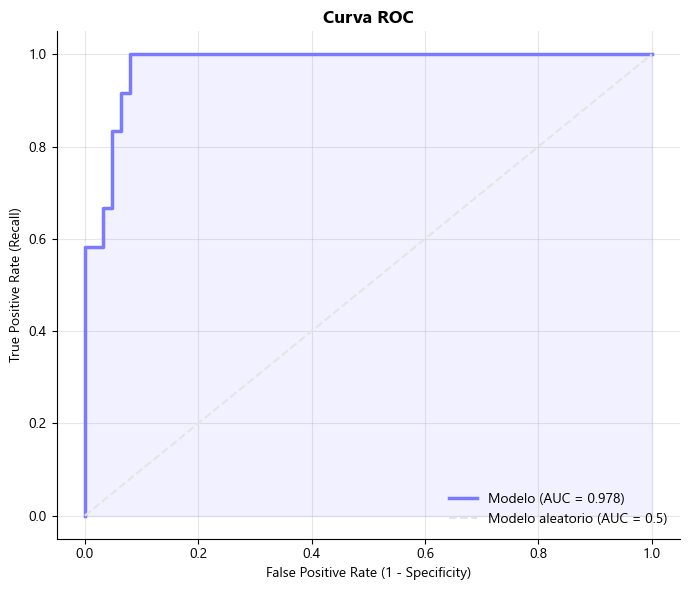

In [24]:
# Visualización de la curva ROC
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color=COLOR_PRINCIPAL, linewidth=2.5,
        label="Modelo (AUC = " + str(round(auc, 3)) + ")")
ax.plot([0, 1], [0, 1], color=COLOR_CONTEXTO, linestyle="--", linewidth=1.5,
        label="Modelo aleatorio (AUC = 0.5)")

ax.fill_between(fpr, tpr, alpha=0.1, color=COLOR_PRINCIPAL)

ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("Curva ROC", fontsize=13, weight="bold")
ax.legend(loc="lower right", frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Benchmark de AUC**:
- 0.5 → modelo aleatorio
- 0.7 - 0.8 → aceptable
- 0.8 - 0.9 → bueno
- > 0.9 → excelente

## 🧮 Paso 12 — Interpretación con Odds Ratios + análisis de threshold

### 12.1 Odds Ratios (cómo se interpreta el modelo)

Un β = −0.4 no se interpreta directamente. Lo correcto es **exponenciarlo** para obtener el **Odds Ratio**: cuánto se multiplican las odds del evento por cada unidad de cambio en X.

In [25]:
# Tabla de Odds Ratios desde statsmodels (con intervalos de confianza)
coefs = modelo_logit.params
conf = modelo_logit.conf_int()
conf.columns = ["IC_2.5", "IC_97.5"]

tabla_or = pd.DataFrame({
    "Coeficiente (β)": coefs.round(4),
    "Odds Ratio (e^β)": np.exp(coefs).round(3),
    "IC 95% inferior": np.exp(conf["IC_2.5"]).round(3),
    "IC 95% superior": np.exp(conf["IC_97.5"]).round(3),
    "p-valor": modelo_logit.pvalues.round(4),
})

tabla_or


,Coeficiente (β),Odds Ratio (e^β),IC 95% inferior,IC 95% superior,p-valor
const,5.5714,262.806,20.256,3409.740,0.0000
Antiguedad_Meses,-0.0303,0.970,0.893,1.054,0.4762
Asistencias_Mes,-0.2756,0.759,0.549,1.050,0.0961
Horas_Pico_Mes,-0.2999,0.741,0.557,0.985,0.0393
Gasto_Mensual_Extra,-0.0380,0.963,0.913,1.015,0.1577


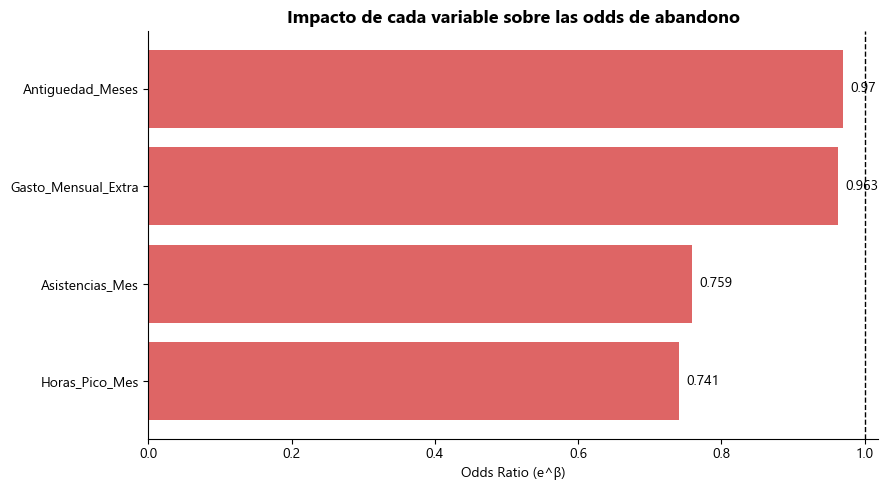

In [26]:
# Visualización de Odds Ratios
tabla_plot = tabla_or.drop("const", errors="ignore").sort_values("Odds Ratio (e^β)")
colores = [COLOR_POSITIVO if v > 1 else COLOR_NEGATIVO for v in tabla_plot["Odds Ratio (e^β)"]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(tabla_plot.index, tabla_plot["Odds Ratio (e^β)"], color=colores, alpha=0.85)
ax.axvline(1, color="black", linestyle="--", linewidth=1)

for i, v in enumerate(tabla_plot["Odds Ratio (e^β)"]):
    ax.text(v + 0.01, i, str(round(v, 3)), va="center", fontsize=10)

ax.set_xlabel("Odds Ratio (e^β)")
ax.set_title("Impacto de cada variable sobre las odds de abandono", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()


**Cómo se lee**:
- OR > 1 → la variable **aumenta** las odds de abandono.
- OR < 1 → la variable **reduce** las odds de abandono.
- Si el IC 95% incluye el 1, la variable no es realmente significativa.

> 💼 **Lectura de negocio típica**: *"Cada asistencia adicional al mes multiplica las odds de abandono por X (las reduce/aumenta un Y %), manteniendo todo lo demás constante."*

### 12.2 Análisis del threshold

Como el dataset está desbalanceado, el threshold por defecto de 0.5 puede no ser óptimo. Vamos a ver cómo se mueven precision, recall, specificity y F1 al variar el threshold.

In [27]:
# Tabla de métricas vs threshold
thresholds_test = np.arange(0.05, 0.95, 0.05)
resultados = []

for th in thresholds_test:
    y_pred_th = (y_prob >= th).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_th).ravel()
    prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    rec = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    spec = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
    f1_t = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    resultados.append([th, prec, rec, spec, f1_t])

df_th = pd.DataFrame(resultados, columns=["Threshold", "Precision", "Recall", "Specificity", "F1"])
df_th.round(3)


,Threshold,Precision,Recall,Specificity,F1
0,0.05,0.545,1.000,0.841,0.706
1,0.10,0.632,1.000,0.889,0.774
2,0.15,0.667,1.000,0.905,0.800
3,0.20,0.733,0.917,0.937,0.815
4,0.25,0.733,0.917,0.937,0.815
5,0.30,0.769,0.833,0.952,0.800
6,0.35,0.727,0.667,0.952,0.696
7,0.40,0.800,0.667,0.968,0.727
8,0.45,0.778,0.583,0.968,0.667
9,0.50,0.875,0.583,0.984,0.700


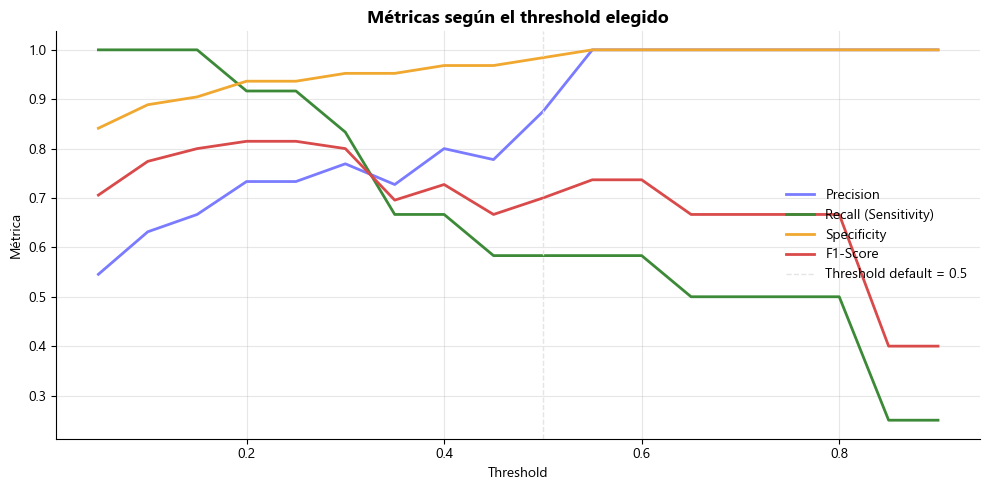

In [28]:
# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_th["Threshold"], df_th["Precision"], color=COLOR_PRINCIPAL, linewidth=2, label="Precision")
ax.plot(df_th["Threshold"], df_th["Recall"], color=COLOR_POSITIVO, linewidth=2, label="Recall (Sensitivity)")
ax.plot(df_th["Threshold"], df_th["Specificity"], color="#f0a830", linewidth=2, label="Specificity")
ax.plot(df_th["Threshold"], df_th["F1"], color=COLOR_NEGATIVO, linewidth=2, label="F1-Score")

ax.axvline(0.5, color=COLOR_CONTEXTO, linestyle="--", linewidth=1, label="Threshold default = 0.5")

ax.set_xlabel("Threshold")
ax.set_ylabel("Métrica")
ax.set_title("Métricas según el threshold elegido", fontsize=13, weight="bold")
ax.legend(loc="center right", frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Threshold que maximiza F1
th_optimo_f1 = df_th.loc[df_th["F1"].idxmax(), "Threshold"]
print("Threshold óptimo según F1:", round(th_optimo_f1, 2))


Threshold óptimo según F1: 0.2


: 

## 🎯 Conclusión de negocio

Tras aplicar la metodología completa al caso del gimnasio:

1. **El modelo es válido**: AUC alto y métricas razonables a pesar del desbalance (16% de positivos).
2. **Variables que más influyen en evitar el abandono** (signos negativos en los coeficientes):
   - Más asistencias al mes
   - Mayor gasto extra
   - Más horas en horario pico
   - Más antigüedad como cliente
3. **Acciones recomendadas al equipo de Customer Success**:
   - Crear una **alerta** para clientes con pocas asistencias en los últimos 30 días.
   - Diseñar **campañas de retención** segmentadas: bonos de extras para reactivar consumo.
   - Si la acción de retención es cara (ej. un mes gratis) → usar threshold alto (más precision).
   - Si la acción es barata (email, llamada) → usar threshold bajo (más recall).
4. **Modelo en producción**: usar `model.predict_proba()` mensualmente sobre la base activa y priorizar la intervención sobre los clientes con probabilidad > umbral elegido según presupuesto.

---

## 📌 Checklist final

- [x] Limpieza completa (nulos, duplicados, outliers)
- [x] Balance de clases analizado
- [x] Data leakage descartado (`Satisfecho` excluida por precaución)
- [x] Split estratificado
- [x] Modelo con statsmodels (interpretación) + sklearn (producción)
- [x] VIF y p-valores comprobados
- [x] Modelo entrenado ANTES de inspeccionar coeficientes
- [x] AUC calculado con `y_prob`, no con `y_pred`
- [x] Las 5 métricas: Accuracy, Precision, Recall, **Specificity**, F1
- [x] Curva ROC con paleta de marca
- [x] Interpretación con Odds Ratios
- [x] Análisis del threshold para tomar decisión de negocio